## Week 2 Day 2 - Orchestration

Our first Agentic Framework project!!

### Part 1: Email Setup

### Part 2: Orchestrating by code

### Part 3: Orchestrating by LLMs

- 3a: via Tools
- 3b: via Handoffs

## Part 1: Email Setup

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/stop.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">IMPORTANT PLEASE READ - Sending Emails</h2>
            <span style="color:#ff7800;">We are going to write an agent that sends emails. The best way to do this is with an email provider
            like SendGrid or Resend. But this requires a fair amount of heavy-lifting: you need to send from a proper email host where you own the domain and you can prove it with DNS records. It's quite a hassle.<br/><br/>
            So we're going to do it the free & simple way: using SMTP server configuration to send direct from your email. It's an easy setup, but it's not as powerful (eg you can't receive emails). If you'd like to take this further, use SendGrid or Resend instead..<br/><br/>
            And actually the email send is optional. We're doing this to demonstrate an Agent sending emails. The important part is the Agent work, not the email sending. Feel free to swap out the function for a Pushover push if you'd prefer.
            </span>
        </td>
    </tr>
</table>

## Setting up to send emails from your SMTP server

### STEP 1: Determining your SMTP Server

Either google or ask ChatGPT / Claude for the SMTP server for your email. Here are some common ones. Some email providers might not have SMTP servers enabled (eg Microsoft 365 for work/school).

Google: smtp.gmail.com  
Outlook.com / Hotmail / Live: smtp-mail.outlook.com  
Microsoft 365: smtp.office365.com  
iCloud Mail: smtp.mail.me.com  

Add to your .env file:  

`EMAIL_SMTP_SERVER=xxxx`

### STEP 2: Obtain an app specific password

Google how to do this for your email provider. For gmail, you need to have 2-step verification on. Then visit this page:

https://myaccount.google.com/apppasswords

Give it any name; copy the password and add it to your .env file, removing the spaces that it adds. (It should be 16 characters, no spaces.)

`EMAIL_APP_PASSWORD=xxxx`

### STEP 3: Add in your email address:

`EMAIL_ADDRESS=xxx`

Remember to Save the .env file!

In [1]:
from dotenv import load_dotenv
import requests
from agents import Agent, Runner, trace, function_tool, ModelSettings
from agents.extensions.visualization import draw_graph
from openai.types.responses import ResponseTextDeltaEvent
import os
import asyncio
import smtplib
from email.message import EmailMessage
load_dotenv(override=True)
os.environ["OPENAI_API_KEY"] = os.environ.get("GROQ_API_KEY") 
os.environ["OPENAI_BASE_URL"] = "https://api.groq.com/openai/v1"
MODEL_NAME = "llama-3.1-8b-instant"

In [2]:
EMAIL_ADDRESS = os.getenv("EMAIL_ADDRESS")
EMAIL_SMTP_SERVER = os.getenv("EMAIL_SMTP_SERVER")
EMAIL_APP_PASSWORD = os.getenv("EMAIL_APP_PASSWORD")

if EMAIL_ADDRESS:
    print("Email address is set")
else:
    print("Email address is not set")

if EMAIL_SMTP_SERVER:
    print("SMTP server is set")
else:
    print("SMTP server is not set")

if EMAIL_APP_PASSWORD:
    print("App password is set")
else:
    print("App password is not set")

USE_EMAIL = EMAIL_ADDRESS and EMAIL_SMTP_SERVER and EMAIL_APP_PASSWORD

if USE_EMAIL:
    print("Email is set up and we will try using it")
else:
    print("Email is not set up; we will send push notifications instead")

Email address is set
SMTP server is set
App password is set
Email is set up and we will try using it


In [3]:
import smtplib
from email.message import EmailMessage

def send_email(subject, text_body, html_body):
    try:
        msg = EmailMessage()
        msg["From"] = EMAIL_ADDRESS
        msg["To"] = EMAIL_ADDRESS
        msg["Subject"] = subject
        msg.set_content(text_body)
        msg.add_alternative(html_body, subtype="html")

        print(f"Connecting to {EMAIL_SMTP_SERVER}...") 
        
        with smtplib.SMTP(EMAIL_SMTP_SERVER, 587) as server:
            server.set_debuglevel(1) 
            server.starttls()
            server.login(EMAIL_ADDRESS, EMAIL_APP_PASSWORD)
            server.send_message(msg)
            print("Email sent successfully!")
            
    except Exception as e:
        print(f"Error: {e}")



In [4]:
send_email("Testing testing 123", "Fingers crossed..", "<html><body><strong>Fingers</strong> crossed..</body></html>")

Connecting to smtp.gmail.com...


send: 'ehlo 1.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.ip6.arpa\r\n'
reply: b'250-smtp.gmail.com at your service, [2400:adc5:428:4200:f8ed:668:f6f5:9992]\r\n'
reply: b'250-SIZE 35882577\r\n'
reply: b'250-8BITMIME\r\n'
reply: b'250-STARTTLS\r\n'
reply: b'250-ENHANCEDSTATUSCODES\r\n'
reply: b'250-PIPELINING\r\n'
reply: b'250-CHUNKING\r\n'
reply: b'250 SMTPUTF8\r\n'
reply: retcode (250); Msg: b'smtp.gmail.com at your service, [2400:adc5:428:4200:f8ed:668:f6f5:9992]\nSIZE 35882577\n8BITMIME\nSTARTTLS\nENHANCEDSTATUSCODES\nPIPELINING\nCHUNKING\nSMTPUTF8'
send: 'STARTTLS\r\n'
reply: b'220 2.0.0 Ready to start TLS\r\n'
reply: retcode (220); Msg: b'2.0.0 Ready to start TLS'
send: 'ehlo 1.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.0.ip6.arpa\r\n'
reply: b'250-smtp.gmail.com at your service, [2400:adc5:428:4200:f8ed:668:f6f5:9992]\r\n'
reply: b'250-SIZE 35882577\r\n'
reply: b'250-8BITMIME\r\n'
reply: b'250-AUTH LOGIN PLAIN XOAUTH2 PLAIN-CLIENTTOKEN OAUTHBEAR

Email sent successfully!


reply: b'250 2.0.0 OK  1784448888 5b1f17b1804b1-495499a5847sm136034755e9.2 - gsmtp\r\n'
reply: retcode (250); Msg: b'2.0.0 OK  1784448888 5b1f17b1804b1-495499a5847sm136034755e9.2 - gsmtp'
data: (250, b'2.0.0 OK  1784448888 5b1f17b1804b1-495499a5847sm136034755e9.2 - gsmtp')
send: 'QUIT\r\n'
reply: b'221 2.0.0 closing connection 5b1f17b1804b1-495499a5847sm136034755e9.2 - gsmtp\r\n'
reply: retcode (221); Msg: b'2.0.0 closing connection 5b1f17b1804b1-495499a5847sm136034755e9.2 - gsmtp'


### If this didn't work, then uncomment the below so that we don't use emails

In [5]:
USE_EMAIL = False

### Our fallback strategy - send a push

In [6]:
pushover_user = os.getenv("PUSHOVER_USER")
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_url = "https://api.pushover.net/1/messages.json"

if pushover_user:
    if pushover_user.startswith("u"):
        print("Pushover user found and looks good")
    else:
        print("Pushover user found but doesn't start with u")
else:
    print("Pushover user not found")

if pushover_token:
    if pushover_token.startswith("a"):
        print("Pushover token found and looks good")
    else:
        print("Pushover token found but doesn't start with a")
else:
    print("Pushover token not found")

Pushover user found and looks good
Pushover token found and looks good


In [7]:
def push(message):
    print(f"Push: {message}")
    payload = {"user": pushover_user, "token": pushover_token, "message": message}
    requests.post(pushover_url, data=payload)

In [8]:
def send_message(subject, text_body, html_body):
    if USE_EMAIL:
        send_email(subject, text_body, html_body)
    else:
        push(f"Subject: {subject}\n\n{text_body}")

### OK Now everything should work!

In [9]:
send_message("Big news", "Communications are a go!", "<html><body>Communications are a <strong>go!</strong></body></html>")

Push: Subject: Big news

Communications are a go!


## Agent Orchestration

There are 2 models for Agent Orchestration; by code and by LLMs.

By code: more predictable and deterministic.

By LLMs: more powerful.

An excellent write-up is here:

https://openai.github.io/openai-agents-python/multi_agent/

We will start with by Code.

## Part 2: Orchestrating by Code

In [10]:
intro = """
You are a sales agent working for ComplAI, 
a company that provides a SaaS tool for ensuring SOC2 compliance and preparing for audits, powered by AI.
You write emails.
"""

instructions1 = intro + "Your email style is professional, serious, with gravitas and credibility."
instructions2 = intro + "Your email style is witty, engaging, and humorous."
instructions3 = intro + "Your email style is concise, to the point, in the style of a busy senior executive."

In [11]:
sales_agent1 = Agent(name="Professional Sales Agent", instructions=instructions1, model="openai/llama-3.1-8b-instant",)
sales_agent2 = Agent(name="Humorous Sales Agent", instructions=instructions2, model="openai/llama-3.1-8b-instant")
sales_agent3 = Agent(name="Executive Sales Agent", instructions=instructions3, model="openai/llama-3.1-8b-instant")


In [12]:

result = Runner.run_streamed(sales_agent1, input="Write a cold sales email")
async for event in result.stream_events():
    if event.type == "raw_response_event" and isinstance(event.data, ResponseTextDeltaEvent):
        print(event.data.delta, end="", flush=True)

Subject: Enhance Your Organization's Security and Compliance with ComplAI

Dear [Recipient's Name],

I am writing to introduce you to ComplAI, a cutting-edge SaaS solution designed to simplify the process of achieving SOC 2 compliance and preparedness for audits. As a compliance expert in the industry, I am confident that our innovative tool can significantly reduce the time, effort, and costs associated with adhering to the stringent security and compliance standards set forth by the American Institute of Certified Public Accountants (AICPA).

ComplAI's AI-powered platform streamlines the compliance process by providing a comprehensive framework for establishing and maintaining effective security controls, risk assessment, and governance. Our tool enables organizations to focus on core operations while our platform ensures compliance with the five trust service principles:

- Security: Protect assets and data from unauthorized access, theft, or destruction
- Availability: Ensure acces

In [13]:
message = "Write a cold sales email"

with trace("Parallel cold emails"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )

outputs = [result.final_output for result in results]

for output in outputs:
    print(output + "\n\n")


Subject: Enhance Your Organization's Cybersecurity Posture with ComplAI

Dear [Recipient's Name],

As a [Title/Position] at [Company Name], you understand the significance of maintaining a robust cybersecurity posture to protect sensitive information and ensure compliance with regulatory requirements. I wanted to bring to your attention a game-changing solution that has been gaining traction in the industry: ComplAI, a SaaS tool powered by AI designed to facilitate SOC2 compliance and prepare for audits.

In today's ever-evolving threat landscape, maintaining compliance and security is a top priority for organizations of all sizes. At ComplAI, our cutting-edge technology leverages machine learning and predictive analytics to identify risk areas, streamline compliance processes, and provide actionable insights to optimize security postures.

Our platform offers the following benefits:

- AI-driven risk assessment and recommendation
- Automated reporting and documentation for SOC2 compli

In [14]:
decision = """
You pick the best cold sales email from the given options.
Imagine you are a customer and pick the one you are most likely to respond to.
Do not give an explanation; reply with the selected email only.
"""

sales_picker = Agent(name="Sales_picker", instructions=decision, model=MODEL_NAME)


In [16]:
# Now in this cell all the 4 agents will be run in parallel and the best email will be selected by the sales_picker agent.
message = "Write a cold sales email"

with trace("Sales selection workflow"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )
    outputs = [result.final_output for result in results]

    emails = "Cold sales emails:\n\n" + "\n\nEmail:\n\n".join(outputs)

    best = await Runner.run(sales_picker, emails)

    print(f"Best sales email:\n{best.final_output}")


Best sales email:
Subject: Compliance Made Cool (We Wish)


[non-fatal] Tracing client error 401: {
  "error": {
    "message": "Incorrect API key provided: gsk_tHe4********************************************TjLh. You can find your API key at https://platform.openai.com/account/api-keys.",
    "type": "invalid_request_error",
    "param": null,
    "code": "invalid_api_key"
  }
}


Now go and check out the trace:

https://platform.openai.com/traces

### Now we will add a tool to the mix.

In [31]:
# @function_tool
# def send_email_tool(subject: str, text_body: str, html_body: str) -> str:
#     """
#     Send out an email with the given subject and body to all sales prospects
    
#     Args:
#         subject: The subject of the email
#         text_body: The body of the email as plain text
#         html_body: The HTML body of the email
#     """
#     push(subject, text_body, html_body)
#     return "Email sent successfully"

@function_tool
def send_email_tool(subject: str, text_body: str, html_body: str) -> str:
    """
    Sends a push notification with the selected email content.
    """
    formatted_message = f"Subject: {subject}\n\n{text_body}"
    push(formatted_message)
    
    return "Notification sent successfully"

### This has automatically been converted into a tool, with the boilerplate json created

In [32]:
send_email_tool.params_json_schema

{'properties': {'subject': {'title': 'Subject', 'type': 'string'},
  'text_body': {'title': 'Text Body', 'type': 'string'},
  'html_body': {'title': 'Html Body', 'type': 'string'}},
 'required': ['subject', 'text_body', 'html_body'],
 'title': 'send_email_tool_args',
 'type': 'object',
 'additionalProperties': False}

In [33]:

decision = """
You are a customer selecting the best cold sales email from the provided options.
Choose the one you are most likely to respond to.
Do not explain your choice. Do not write any conversational text before or after.
Immediately and strictly call the send_email_tool with the arguments extracted from the chosen email.
"""

require_tool = ModelSettings(tool_choice="required")

# sales_sender = Agent(name="Sales Sender", instructions=decision, model="llama-3.3-70b-versatile", tools=[send_email_tool], model_settings=require_tool)
sales_sender = Agent(name="Sales Sender", instructions=decision, model="llama-3.3-70b-versatile", tools=[send_email_tool])

In [ ]:
message = "Write a cold sales email"

with trace("Sales selection workflow with sending"):
    results = await asyncio.gather(
        
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )
    outputs = [result.final_output for result in results]

    emails = "Cold sales emails:\n\n" + "\n\nEmail:\n\n".join(outputs)
    await asyncio.sleep(3)
    response = await Runner.run(sales_sender, emails)

    print(f"Final response:\n{response.final_output}")

### Did that work?!

See the traces for more! This is a great way to debug. Smaller models might require more time and experimentation.

https://platform.openai.com/traces

## Part 3: Orchestrating by LLMs

### 3a: via Tools

The simplest way to have 1 Agent choose to invoke another is by treating it as a tool call.

The OpenAI Agents SDK gives a very simple way to do this.

This works best when the flow is:

Agent A -> Agent B -> Agent A

And for the classic "Planning Agent" situation.

In [35]:
description = "Use this tool to write a sales email. In the input, just instruct it to write a sales email." 

tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool1

FunctionTool(name='sales_email_writer_1', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'AgentAsToolInput', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<agents.tool._FailureHandlingFunctionToolInvoker object at 0x114ff1dc0>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None, needs_approval=False, timeout_seconds=None, timeout_behavior='error_as_result', timeout_error_function=None, defer_loading=False, custom_data_extractor=None)

### So now we can gather all the tools together:

A tool for each of our 3 email-writing agents

And a tool for our function to send emails

In [36]:
tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool2 = sales_agent2.as_tool(tool_name="sales_email_writer_2", tool_description=description)
tool3 = sales_agent3.as_tool(tool_name="sales_email_writer_3", tool_description=description)

tools = [tool1, tool2, tool3, send_email_tool]

tools

[FunctionTool(name='sales_email_writer_1', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'AgentAsToolInput', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<agents.tool._FailureHandlingFunctionToolInvoker object at 0x1150cf1d0>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None, needs_approval=False, timeout_seconds=None, timeout_behavior='error_as_result', timeout_error_function=None, defer_loading=False, custom_data_extractor=None),
 FunctionTool(name='sales_email_writer_2', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'inp

## And now it's time for our Sales Manager - our planning agent

In [37]:
instructions = """
You are a Sales Manager at ComplAI. Your goal is to find the single best cold sales email using the sales_writer tools.
"""

task = """
Follow these steps:

1. Generate Drafts: Use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed until all three drafts are ready, one from each tool.
 
2. Evaluate and Select: Review the drafts and choose the single best email using your judgment of which one is most effective.
 
3. Use your tool to send the best email (and only the best email) to the user. Only send 1 email.
"""

sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, model="llama-3.1-8b-instant")
# Giving the manager tools 

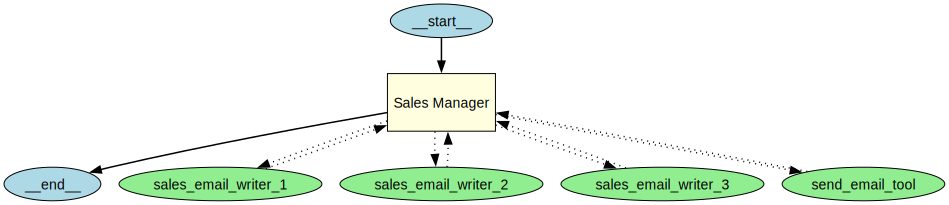

In [38]:
draw_graph(sales_manager)

In [43]:
# with trace("Sales manager"):
result = await Runner.run(sales_manager, task)

[non-fatal] Tracing client error 401: {
  "error": {
    "message": "Incorrect API key provided: gsk_tHe4********************************************TjLh. You can find your API key at https://platform.openai.com/account/api-keys.",
    "type": "invalid_request_error",
    "param": null,
    "code": "invalid_api_key"
  }
}


Push: Subject: Achieve SOC2 Compliance with Ease

Dear [Prospect's Name],
I came across your company and noticed that you handle sensitive client information, making SOC2 compliance a critical requirement. I'm reaching out to introduce ComplAI, a cutting-edge SaaS tool that streamlines SOC2 compliance and audit preparation.
Our AI-powered platform simplifies the process by:
- Automating documentation and reporting
- Identifying control gaps and providing corrective actions
- Preparing your team for audits with tailored training
With ComplAI, you can reduce compliance costs by up to 70% and decrease audit preparation time by 90%. If you're ready to achieve SOC2 compliance with ease, I'd be happy to schedule a demo and explore how ComplAI can benefit your organization.
Best regards,
Sales Agent, ComplAI
[Your Contact Information]


[non-fatal] Tracing client error 401: {
  "error": {
    "message": "Incorrect API key provided: gsk_tHe4********************************************TjLh. You can find your API key at https://platform.openai.com/account/api-keys.",
    "type": "invalid_request_error",
    "param": null,
    "code": "invalid_api_key"
  }
}


## Remember to check the trace

https://platform.openai.com/traces

And then check your email!! Also look in your Junk / Spam folder - after all, this is basically a spam message..


<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/stop.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Unreliable results?</h2>
            <span style="color:#ff7800;">This is par for the course with Agentic AI, and particularly with Orchestrating by LLM.
            To resolve it, you'll need to experiment and iterate with the prompts. Particularly with smaller models, more experiments
            may be needed to get reliable outcomes.
            </span>
        </td>
    </tr>
</table>

## Part 3: Orchestrating by LLMs

### 3a: via Handoffs

I am not a fan of handoffs. They seem very unreliable. They're not used consistently by other frameworks.

Behind the scenes, OpenAI Agents SDK has implemented these with Tools anyway.

### Handoffs represent a way an agent can delegate to an agent, passing control to it

Handoffs and Agents-as-tools are similar:

In both cases, an Agent can collaborate with another Agent

With tools, control passes back

A -> B -> A

With handoffs, control passes across

A -> B

In [44]:

instructions = """
You are a Sales Manager at ComplAI. You get your sales team to draft emails, then send them all to a sales picker.
"""

task = """
Follow these steps:

1. Generate Drafts: Use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed until all three drafts are ready, one from each tool.
 
2. Handoff to the sales sender to choose and send the best email.
"""

tools = [tool1, tool2, tool3]
handoffs = [sales_sender]

sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, handoffs=handoffs, model=MODEL_NAME)


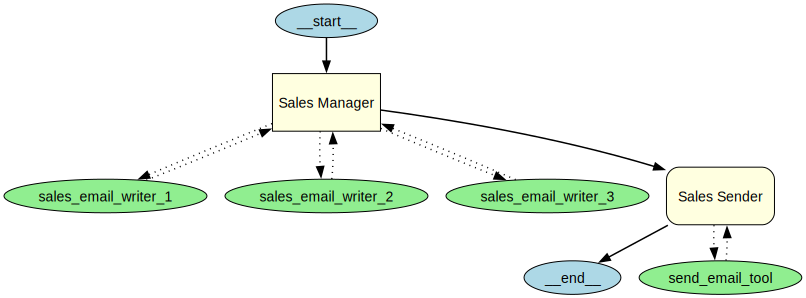

In [45]:
draw_graph(sales_manager)

In [ ]:
with trace("Sales manager"):
    result = await Runner.run(sales_manager, task)